<a href="https://colab.research.google.com/github/mathewsabby05-gif/Weather-Prediction-ML-Project/blob/main/Weather_prediction(git).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data/weather.csv'
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Basic Data Exploration
print("Dataset Shape:", df.shape)
print(df.head())

print(df.info())

Dataset Shape: (145460, 23)
         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  Rai

In [5]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


In [6]:
# 6. Feature Engineering
# Extract Date Features
# -----------------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day

    # Drop original Date column
    df.drop('Date', axis=1, inplace=True)
else:
    print("'Date' column not found. It might have been processed already.")

In [7]:
# Separate Features & Target
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Convert target to numeric
y = y.map({'No':0, 'Yes':1})

# Drop rows where y is NaN and the corresponding rows in X
nan_indices = y[y.isna()].index
X = X.drop(nan_indices)
y = y.drop(nan_indices)

In [8]:
# Identify Columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

In [9]:
# Handle Missing Values
# Numerical columns → Median
for col in numerical_cols:
    X[col].fillna(X[col].median(), inplace=True)

# Categorical columns → Mode
for col in categorical_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

In [10]:
# Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

In [11]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# Train Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print("="*50)
    print(name)
    print("Accuracy:", round(accuracy*100,2), "%")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 84.55 %
[[20811  1287]
 [ 3108  3233]]
              precision    recall  f1-score   support

         0.0       0.87      0.94      0.90     22098
         1.0       0.72      0.51      0.60      6341

    accuracy                           0.85     28439
   macro avg       0.79      0.73      0.75     28439
weighted avg       0.84      0.85      0.84     28439

Decision Tree
Accuracy: 78.99 %
[[19001  3097]
 [ 2878  3463]]
              precision    recall  f1-score   support

         0.0       0.87      0.86      0.86     22098
         1.0       0.53      0.55      0.54      6341

    accuracy                           0.79     28439
   macro avg       0.70      0.70      0.70     28439
weighted avg       0.79      0.79      0.79     28439

Random Forest
Accuracy: 85.22 %
[[21109   989]
 [ 3214  3127]]
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91     22098
         1.0       0.76      0.49      0.6

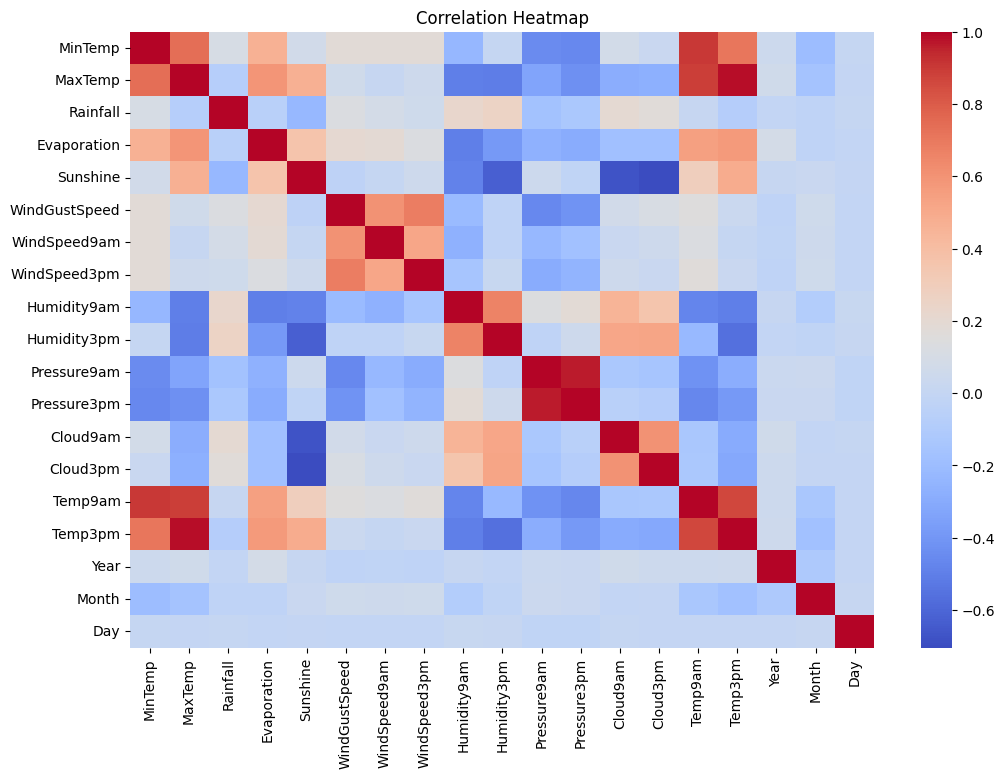

In [17]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [19]:
# Final Result
print("Project Completed Successfully!")

Project Completed Successfully!
